# Bistable mean-field — multi-root + stability demo

Showcases the new DAE-based MF machinery in `pipeline._mean_field_dae`:

* **Multi-start Newton** finds every fixed point of the algebraic
  system obtained by setting `Dt → 0` in each `.equation(lhs=...,
  rhs=...)` declaration.
* **Linear stability** is classified at every root via the
  generalized eigenvalue problem on the DAE Jacobian.
* `compute_cumulants(..., fixed_point_index=N)` selects which
  **stable** branch to expand around — the index enumerates only
  stable roots, sorted ascending by the first physical field's
  first index.  Unstable roots remain inspectable via
  `th['mf_unstable_roots']` but are not addressable as expansion
  points (the diagrammatic series is undefined around an unstable
  saddle).

Model: single-population Hawkes-like voltage with **sigmoidal**
transfer `φ(v) = tanh(g·v)`.  At `Em = 0, w = 2, g = 2` the
self-consistent rate equation `n = tanh(2 · (0 + 2n))` has three
roots — two stable outer branches and one unstable middle branch.
Two stable → `fixed_point_index ∈ {0, 1}`.  Theory file:
`theories/single_population_bistable_demo.theory.py`.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from tests.phase_j_refactor_fixtures._runner import _load_theory
from pipeline import compute_cumulants
from pipeline._mean_field_dae import solve_mean_field_dae, linear_stability

## 1. Load the theory + fundamental parameters

In [2]:
model = _load_theory('single_population_bistable_demo.theory.py')
fundamental = {'Em':[0.0], 'tau':[1.0], 'w':[[2.0]], 'g_gain':[2.0]}
seed_box = {'n': (-1.5, 1.5), 'v': (-3.0, 3.0)}
print(f'model: {model["name"]}')
print(f'  state variables: {[f["name"] for f in model["physical_fields"]]}')
print(f'  declared equations: {len(model["equations"])}')
for i, eq in enumerate(model['equations']):
    print(f'    [{i}] ({eq["kind"]:13s})  {eq["lhs_text"]} = {eq["rhs_text"]}')
print(f'fundamental: {fundamental}')

model: Single population Bistable Demo
  state variables: ['dn', 'dv']
  declared equations: 2
    [0] (differential )  (tau[i]*Dt + 1) * v[i] = Em[i] + sum(w[i, j]*n[j] for j in E)
    [1] (algebraic    )  n[i] = phi[i](v[i])
fundamental: {'Em': [0.000000000000000], 'tau': [1.00000000000000], 'w': [[2.00000000000000]], 'g_gain': [2.00000000000000]}


## 2. Direct DAE solve — find all fixed points + classify stability

Calling `solve_mean_field_dae` / `linear_stability` directly (no
diagrammatic machinery) — fast, isolates the new MF behavior.

In [3]:
res = solve_mean_field_dae(model, fundamental, n_starts=64, seed_box=seed_box)
n_total   = len(res['mf_all_roots'])
n_stable  = len(res['mf_stable_roots'])
n_unstable = n_total - n_stable
print(f'{n_total} distinct fixed point(s) found '
      f'({res["n_seeds_converged"]}/64 seeds converged)')
print(f'  stable:   {n_stable}     '
      f'(selectable via compute_cumulants(fixed_point_index=N))')
print(f'  unstable: {n_unstable}     '
      f'(inspectable via th["mf_unstable_roots"], not selectable)')
print()
print(f'{"idx":>3}  {"n*":>9}  {"v*":>9}  {"stability":>10}  {"finite σ":>25}')
for i, entry in enumerate(res['mf_all_roots']):
    r    = entry['values']
    stab = entry['stable']
    eigs = ', '.join(f'{e.real:+.4f}' for e in entry['eigenvalues_finite'])
    cls  = 'STABLE' if stab else 'UNSTABLE'
    print(f'{i:>3}  {r["nstar"][0]:+9.4f}  {r["vstar"][0]:+9.4f}'
          f'  {cls:>10}  [{eigs}]')

3 distinct fixed point(s) found (60/64 seeds converged)
  stable:   2     (selectable via compute_cumulants(fixed_point_index=N))
  unstable: 1     (inspectable via th["mf_unstable_roots"], not selectable)

idx         n*         v*   stability                   finite σ
  0    -0.9993    -1.9987      STABLE  [-0.9946]
  1    +0.0000    +0.0000    UNSTABLE  [+3.0000]
  2    +0.9993    +1.9987      STABLE  [-0.9946]


## 3. Visualize the three fixed points

Plot the rate self-consistency curve `f(n) = tanh(g·(Em + w·n))`
against the identity line.  Intersections are the MF fixed points;
their stability follows from `|f'(n)| < 1` (stable) vs `> 1`
(unstable).

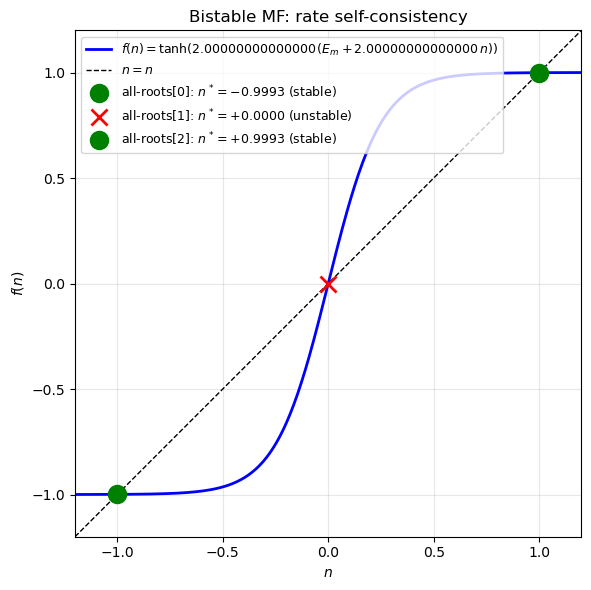

In [4]:
g_gain = fundamental['g_gain'][0]
w      = fundamental['w'][0][0]
Em     = fundamental['Em'][0]
def f(n): return np.tanh(g_gain * (Em + w * n))
n_grid = np.linspace(-1.2, 1.2, 401)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(n_grid, f(n_grid), 'b-', lw=2, label=f'$f(n)=\\tanh({g_gain}\\,(E_m + {w}\\,n))$')
ax.plot(n_grid, n_grid, 'k--', lw=1, label='$n=n$')
for i, entry in enumerate(res['mf_all_roots']):
    r      = entry['values']
    stable = entry['stable']
    n_star = r['nstar'][0]
    color  = 'green' if stable else 'red'
    marker = 'o' if stable else 'x'
    label  = f'all-roots[{i}]: $n^*={n_star:+.4f}$ ({"stable" if stable else "unstable"})'
    ax.plot(n_star, n_star, marker, color=color, markersize=12, mew=2, label=label)
ax.set_xlabel('$n$'); ax.set_ylabel('$f(n)$')
ax.set_title('Bistable MF: rate self-consistency')
ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
plt.tight_layout(); plt.show()

## 4. Full pipeline — `compute_cumulants` around each stable root

Run the full diagrammatic pipeline at each `fixed_point_index ∈
{0, 1}` (the two stable branches).  Different stable MF roots
produce different propagators (different Jacobian poles) →
different cumulant magnitudes.  Tree-level k=1 is the simplest
readout — it just IS the chosen `n*`.  Trying `fixed_point_index = 2`
below would clamp to 1 with a warning, since only two stable
roots exist.

In [5]:
results = []
for idx in [0, 1]:                            # STABLE branches only
    th = compute_cumulants(
        model=model, k=1, max_ell=0, fundamental=fundamental,
        external_fields=[('n', 1)],
        tau_max=1.0, tau_step=1.0,
        parallel=False, use_cache=False, verbose=False,
        fixed_point_index=idx,
        mf_dae_seed_box=seed_box,
    )
    results.append(th)
    stab = th['mf_stability']
    n_star = th['mf_values']['nstar'][0]
    eigs = ', '.join(f'{e.real:+.4f}' for e in stab['eigenvalues_finite'])
    print(f'  fixed_point_index={idx}: n*={n_star:+.4f}  STABLE  '
          f'eigs=[{eigs}]')

# The unstable middle root is still surfaced in th['mf_unstable_roots']
# but isn't selectable via fixed_point_index.
print()
print('mf_unstable_roots (informational, not selectable):')
for r in results[0]['mf_unstable_roots']:
    print(f'  n*={r["nstar"][0]:+.4f}, v*={r["vstar"][0]:+.4f}')

=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM


  fixed_point_index=0: n*=-0.9993  STABLE  eigs=[-0.9946]


=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM


  fixed_point_index=1: n*=+0.9993  STABLE  eigs=[-0.9946]

mf_unstable_roots (informational, not selectable):
  n*=+0.0000, v*=+0.0000


## 5. k=2 covariance at τ=0 around each root

The connected 2-point cumulant `⟨n(0)·n(0)⟩_c` at the same time
differs across the three roots: the unstable middle branch has
diverging fluctuations as the linearized dynamics blow up, while
the two outer branches give finite covariances symmetric about
`n=0`.

In [6]:
for idx in [0, 1]:                            # STABLE branches only
    th = compute_cumulants(
        model=model, k=2, max_ell=0, fundamental=fundamental,
        external_fields=[('n', 1), ('n', 1)],
        tau_max=4.0, tau_step=1.0,
        parallel=False, use_cache=False, verbose=False,
        fixed_point_index=idx,
        mf_dae_seed_box=seed_box,
    )
    c00 = complex(th['total_C'](0.0, 0.0)).real
    print(f'  idx={idx}: n*={th["mf_values"]["nstar"][0]:+.4f}  '
          f'C(τ=0)={c00:+.4e}')

=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM


  idx=0: n*=-0.9993  C(τ=0)=-1.4610e-05


=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM


  idx=1: n*=+0.9993  C(τ=0)=+1.4610e-05


---
**Summary** — three fixed points found, two stable / one unstable,
selected via a single integer kwarg on `compute_cumulants`.  The
diagrammatic machinery downstream is identical to single-root
theories; only the saddle expansion point changes.